In [1]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd
import glob
import os

# ==============================
# PATHS
# ==============================
input_folder = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland"
output_file = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\ireland_20homes_consumption.csv"

# ==============================
# FIND FILES
# ==============================
files = sorted(glob.glob(os.path.join(input_folder, "H*_W.csv")))

all_homes = []

# ==============================
# LOOP OVER HOUSEHOLDS
# ==============================
for i, file in enumerate(files, start=1):
    
    print(f"Processing {file}")
    
    df = pd.read_csv(file)
    
    # ---- Detect consumption column automatically ----
    consumption_col = None
    for col in df.columns:
        if "Consumption" in col:
            consumption_col = col
            break
    
    if consumption_col is None:
        raise ValueError(f"No consumption column found in {file}")
    
    # ---- Keep timestamp + consumption ----
    df = df[['date', consumption_col]].copy()
    
    # Rename columns
    df.rename(columns={
        'date': 'timestamp',
        consumption_col: f'home_{i}'
    }, inplace=True)
    
    # Convert timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Set index for merge
    df.set_index('timestamp', inplace=True)
    
    all_homes.append(df)

# ==============================
# MERGE ALL HOMES
# ==============================
final_df = pd.concat(all_homes, axis=1)

# Reset index back to column
final_df.reset_index(inplace=True)

# Sort just in case
final_df.sort_values("timestamp", inplace=True)

Processing C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\H10_W.csv
Processing C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\H11_W.csv
Processing C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\H12_W.csv
Processing C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\H13_W.csv
Processing C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\H14_W.csv
Processing C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\H15_W.csv
Processing C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\H16_W.csv
Processing C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Ireland\H17_W.csv
Processing C:\Users\CR58XM\Docum

In [4]:
final_df

,timestamp,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,...,home_11,home_12,home_13,home_14,home_15,home_16,home_17,home_18,home_19,home_20
0,2020-01-01 01:00:00,244.0,210.0,358.0,167.0,638.0,702.0,686.0,287.0,833.0,...,95.0,320.0,670.0,294.0,251.0,2195.0,527.0,440.0,593.0,715.0
1,2020-01-01 01:01:00,245.0,210.0,411.0,167.0,636.0,702.0,615.0,286.0,833.0,...,95.0,493.0,668.0,301.0,249.0,2090.0,523.0,425.0,590.0,788.0
2,2020-01-01 01:02:00,245.0,212.0,204.0,167.0,636.0,700.0,607.0,286.0,829.0,...,95.0,736.0,666.0,299.0,241.0,2125.0,526.0,543.0,592.0,773.0
3,2020-01-01 01:03:00,245.0,209.0,198.0,167.0,634.0,698.0,594.0,397.0,827.0,...,94.0,697.0,666.0,299.0,251.0,2024.0,264.0,1414.0,1350.0,772.0
4,2020-01-01 01:04:00,245.0,210.0,212.0,156.0,633.0,674.0,553.0,388.0,825.0,...,93.0,689.0,667.0,395.0,243.0,1873.0,214.0,1410.0,3615.0,848.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527035,2021-01-01 00:55:00,1225.0,660.0,221.0,422.0,NaN,529.0,302.0,220.0,2850.0,...,264.0,1166.0,195.0,663.0,NaN,26.0,605.0,1241.0,787.0,516.0
527036,2021-01-01 00:56:00,1222.0,656.0,218.0,418.0,NaN,520.0,296.0,218.0,1462.0,...,230.0,1160.0,139.0,743.0,NaN,26.0,601.0,1292.0,787.0,516.0
527037,2021-01-01 00:57:00,1285.0,658.0,215.0,488.0,NaN,519.0,296.0,218.0,1449.0,...,223.0,1161.0,125.0,785.0,NaN,26.0,603.0,1300.0,783.0,511.0
527038,2021-01-01 00:58:00,1311.0,658.0,213.0,309.0,NaN,521.0,294.0,220.0,1175.0,...,224.0,1161.0,127.0,778.0,NaN,29.0,600.0,1372.0,787.0,NaN


In [ ]:
# =========================
# Set timestamp as index
# =========================
final_df['timestamp'] = pd.to_datetime(final_df['timestamp'])
final_df.set_index('timestamp', inplace=True)

# =========================
# Resample to 15 minutes
# =========================
df_15min = final_df.resample('15T').mean()



                          home_1      home_2  home_3      home_4      home_5  \
timestamp                                                                      
2020-01-01 01:00:00   897.333333  422.733333   322.6  152.733333  618.000000   
2020-01-01 01:15:00  1155.200000  805.000000   200.4  183.866667  316.666667   
2020-01-01 01:30:00  1123.066667  298.133333   232.4  153.266667  184.733333   
2020-01-01 01:45:00  1104.333333  269.066667   101.6  144.600000  232.133333   
2020-01-01 02:00:00  1134.066667  143.533333   115.6  185.733333  254.666667   

                         home_6      home_7      home_8       home_9  \
timestamp                                                              
2020-01-01 01:00:00  695.666667  582.600000  352.400000   990.733333   
2020-01-01 01:15:00  584.466667  752.000000  306.466667  1014.800000   
2020-01-01 01:30:00  648.600000  761.142857  286.333333   872.066667   
2020-01-01 01:45:00  730.200000  706.000000  308.333333   857.933333   
2020-01

C:\Users\CR58XM\AppData\Local\Temp\ipykernel_15724\2568075780.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15min = final_df.resample('15T').mean()


In [6]:
df_15min

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,home_11,home_12,home_13,home_14,home_15,home_16,home_17,home_18,home_19,home_20
timestamp,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00,897.333333,422.733333,322.600000,152.733333,618.000000,695.666667,582.600000,352.400000,990.733333,546.933333,93.800000,668.666667,691.933333,345.866667,458.866667,1766.666667,349.666667,1146.666667,2867.666667,953.933333
2020-01-01 01:15:00,1155.200000,805.000000,200.400000,183.866667,316.666667,584.466667,752.000000,306.466667,1014.800000,424.857143,101.133333,378.733333,695.666667,421.133333,159.066667,1210.733333,328.066667,1236.400000,3549.133333,897.733333
2020-01-01 01:30:00,1123.066667,298.133333,232.400000,153.266667,184.733333,648.600000,761.142857,286.333333,872.066667,398.400000,146.333333,350.866667,596.266667,493.266667,144.000000,884.666667,285.733333,1207.133333,3461.533333,779.000000
2020-01-01 01:45:00,1104.333333,269.066667,101.600000,144.600000,232.133333,730.200000,706.000000,308.333333,857.933333,337.400000,50.000000,313.866667,341.800000,215.133333,142.933333,742.000000,239.866667,1168.133333,3553.533333,740.866667
2020-01-01 02:00:00,1134.066667,143.533333,115.600000,185.733333,254.666667,898.533333,705.333333,353.533333,878.733333,291.800000,44.333333,167.200000,363.333333,339.066667,143.666667,443.133333,476.133333,1274.800000,3332.800000,803.466667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 23:45:00,1288.466667,729.066667,162.933333,561.066667,NaN,782.666667,396.933333,214.800000,1564.666667,1310.000000,355.200000,2097.133333,633.200000,939.000000,3334.800000,153.000000,614.800000,2078.733333,582.666667,444.200000
2021-01-01 00:00:00,1119.666667,728.400000,84.600000,2248.000000,NaN,765.533333,400.666667,217.333333,1061.466667,1318.000000,301.400000,2163.133333,696.666667,1038.384615,NaN,189.800000,741.000000,2027.533333,782.800000,517.800000
2021-01-01 00:15:00,1495.866667,791.000000,156.266667,590.733333,NaN,639.466667,774.800000,251.800000,1133.333333,1029.333333,260.533333,2109.200000,679.928571,715.266667,NaN,50.000000,702.133333,1883.333333,828.600000,552.000000


In [7]:
# Check total missing values per column
missing_per_home = df_15min.isna().sum()

print("Missing values per home:")
print(missing_per_home)


# Total missing values in dataframe
total_missing = df_15min.isna().sum().sum()
print("\nTotal missing values:", total_missing)


# Percentage missing per column
missing_percent = df_15min.isna().mean() * 100

print("\nMissing percentage per home:")
print(missing_percent)


# Check timestamps that contain ANY missing value
missing_rows = df_15min[df_15min.isna().any(axis=1)]

print("\nNumber of timestamps with missing data:", len(missing_rows))

Missing values per home:
home_1       78
home_2      136
home_3      138
home_4      175
home_5     2664
home_6       74
home_7     1213
home_8       75
home_9       80
home_10     131
home_11      51
home_12      61
home_13      20
home_14      11
home_15     123
home_16      44
home_17     187
home_18      60
home_19      70
home_20      76
dtype: int64

Total missing values: 5467

Missing percentage per home:
home_1     0.221995
home_2     0.387067
home_3     0.392760
home_4     0.498065
home_5     7.581967
home_6     0.210610
home_7     3.452300
home_8     0.213456
home_9     0.227687
home_10    0.372837
home_11    0.145150
home_12    0.173611
home_13    0.056922
home_14    0.031307
home_15    0.350068
home_16    0.125228
home_17    0.532218
home_18    0.170765
home_19    0.199226
home_20    0.216302
dtype: float64

Number of timestamps with missing data: 4752


In [11]:
df_15min

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,home_11,home_12,home_13,home_14,home_15,home_16,home_17,home_18,home_19,home_20
timestamp,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00,897.333333,422.733333,322.600000,152.733333,618.000000,695.666667,582.600000,352.400000,990.733333,546.933333,93.800000,668.666667,691.933333,345.866667,458.866667,1766.666667,349.666667,1146.666667,2867.666667,953.933333
2020-01-01 01:15:00,1155.200000,805.000000,200.400000,183.866667,316.666667,584.466667,752.000000,306.466667,1014.800000,424.857143,101.133333,378.733333,695.666667,421.133333,159.066667,1210.733333,328.066667,1236.400000,3549.133333,897.733333
2020-01-01 01:30:00,1123.066667,298.133333,232.400000,153.266667,184.733333,648.600000,761.142857,286.333333,872.066667,398.400000,146.333333,350.866667,596.266667,493.266667,144.000000,884.666667,285.733333,1207.133333,3461.533333,779.000000
2020-01-01 01:45:00,1104.333333,269.066667,101.600000,144.600000,232.133333,730.200000,706.000000,308.333333,857.933333,337.400000,50.000000,313.866667,341.800000,215.133333,142.933333,742.000000,239.866667,1168.133333,3553.533333,740.866667
2020-01-01 02:00:00,1134.066667,143.533333,115.600000,185.733333,254.666667,898.533333,705.333333,353.533333,878.733333,291.800000,44.333333,167.200000,363.333333,339.066667,143.666667,443.133333,476.133333,1274.800000,3332.800000,803.466667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 23:45:00,1288.466667,729.066667,162.933333,561.066667,NaN,782.666667,396.933333,214.800000,1564.666667,1310.000000,355.200000,2097.133333,633.200000,939.000000,3334.800000,153.000000,614.800000,2078.733333,582.666667,444.200000
2021-01-01 00:00:00,1119.666667,728.400000,84.600000,2248.000000,NaN,765.533333,400.666667,217.333333,1061.466667,1318.000000,301.400000,2163.133333,696.666667,1038.384615,NaN,189.800000,741.000000,2027.533333,782.800000,517.800000
2021-01-01 00:15:00,1495.866667,791.000000,156.266667,590.733333,NaN,639.466667,774.800000,251.800000,1133.333333,1029.333333,260.533333,2109.200000,679.928571,715.266667,NaN,50.000000,702.133333,1883.333333,828.600000,552.000000


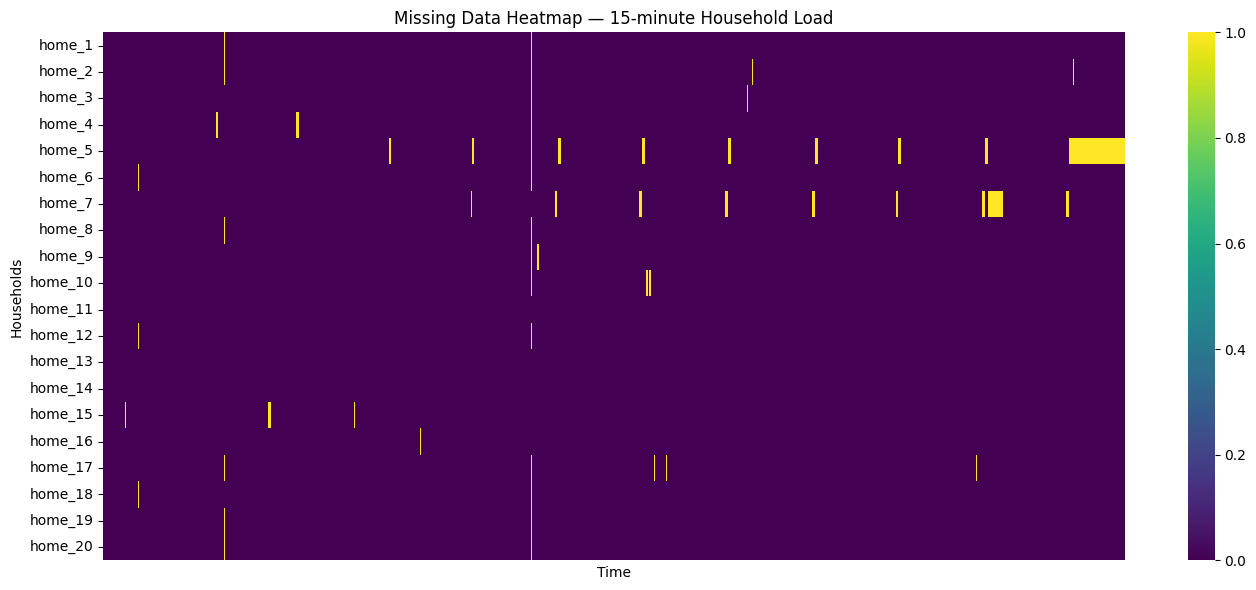

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boolean mask of missing values
missing_mask = df_15min.isna()

plt.figure(figsize=(14, 6))

sns.heatmap(
    missing_mask.T,        # transpose → homes on y-axis
    cmap="viridis",
    cbar=True,
    xticklabels=False
)

plt.title("Missing Data Heatmap — 15-minute Household Load")
plt.xlabel("Time")
plt.ylabel("Households")

plt.tight_layout()
plt.show()

In [8]:
start_ts = df_15min.index.min()
end_ts   = df_15min.index.max()

In [9]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# --- Get start/end from power_selected ---

start_ts = df_15min.index.min()
end_ts   = df_15min.index.max()

start_date = start_ts.strftime("%Y-%m-%d")
end_date   = end_ts.strftime("%Y-%m-%d")

print("Power period:", start_ts, "→", end_ts)
print("Weather API dates:", start_date, "→", end_date)

# --- Setup client (cache forever is fine; you can also use expire_after=3600) ---
cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# --- Historical archive endpoint ---
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 52.1408,
    "longitude": -10.2689,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "precipitation",
        "direct_radiation",
    ],
    "timezone": "UTC",
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# --- Parse hourly data (order must match params["hourly"]) ---
hourly = response.Hourly()

hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(3).ValuesAsNumpy()
hourly_direct_radiation = hourly.Variables(4).ValuesAsNumpy()

hourly_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

weather_hourly = pd.DataFrame(
    {
        "temperature_2m": hourly_temperature_2m,
        "relative_humidity_2m": hourly_relative_humidity_2m,
        "wind_speed_10m": hourly_wind_speed_10m,
        "precipitation": hourly_precipitation,
        "direct_radiation": hourly_direct_radiation,
    },
    index=hourly_index,
)

print("\nWeather hourly head:\n", weather_hourly.head())
print("\nWeather hourly tail:\n", weather_hourly.tail())




# --- Convert to 15-min to match power_selected timestamps ---
weather_15min = weather_hourly.resample("15min").interpolate("time")


Power period: 2020-01-01 01:00:00 → 2021-01-01 00:45:00
Weather API dates: 2020-01-01 → 2021-01-01
Coordinates: 52.12653732299805°N -10.2762451171875°E
Elevation: 14.0 m asl
Timezone difference to GMT+0: 0s

Weather hourly head:
                            temperature_2m  relative_humidity_2m  \
2020-01-01 00:00:00+00:00            5.80             96.258575   
2020-01-01 01:00:00+00:00            7.00             93.352226   
2020-01-01 02:00:00+00:00            6.85             93.667732   
2020-01-01 03:00:00+00:00            6.85             93.667732   
2020-01-01 04:00:00+00:00            6.70             94.310524   

                           wind_speed_10m  precipitation  direct_radiation  
2020-01-01 00:00:00+00:00        7.594208            0.0               0.0  
2020-01-01 01:00:00+00:00        5.001280            0.0               0.0  
2020-01-01 02:00:00+00:00        7.993297            0.0               0.0  
2020-01-01 03:00:00+00:00        8.373386            0.0   

In [ ]:
df

In [10]:
weather_15min

,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
2020-01-01 00:00:00+00:00,5.80,96.258575,7.594208,0.0,0.0
2020-01-01 00:15:00+00:00,6.10,95.531990,6.945976,0.0,0.0
2020-01-01 00:30:00+00:00,6.40,94.805405,6.297744,0.0,0.0
2020-01-01 00:45:00+00:00,6.70,94.078812,5.649512,0.0,0.0
2020-01-01 01:00:00+00:00,7.00,93.352226,5.001280,0.0,0.0
...,...,...,...,...,...
2021-01-01 22:00:00+00:00,4.25,83.188660,11.384198,0.0,0.0
2021-01-01 22:15:00+00:00,4.20,83.557877,11.259068,0.0,0.0
2021-01-01 22:30:00+00:00,4.15,83.927086,11.133937,0.0,0.0
2021-01-01 22:45:00+00:00,4.10,84.296295,11.008806,0.0,0.0


In [12]:
# Make sure both indices are datetime and aligned
df_15min.index = pd.to_datetime(df_15min.index)
weather_15min.index = pd.to_datetime(weather_15min.index)

# If timezone exists in one and not the other → align
if df_15min.index.tz != weather_15min.index.tz:
    weather_15min = weather_15min.tz_convert(df_15min.index.tz) if weather_15min.index.tz else weather_15min.tz_localize(df_15min.index.tz)

# Join weather to the right
df_with_weather = df_15min.join(weather_15min, how="left")

print(df_with_weather.head())
print(df_with_weather.shape)

                          home_1      home_2  home_3      home_4      home_5  \
timestamp                                                                      
2020-01-01 01:00:00   897.333333  422.733333   322.6  152.733333  618.000000   
2020-01-01 01:15:00  1155.200000  805.000000   200.4  183.866667  316.666667   
2020-01-01 01:30:00  1123.066667  298.133333   232.4  153.266667  184.733333   
2020-01-01 01:45:00  1104.333333  269.066667   101.6  144.600000  232.133333   
2020-01-01 02:00:00  1134.066667  143.533333   115.6  185.733333  254.666667   

                         home_6      home_7      home_8       home_9  \
timestamp                                                              
2020-01-01 01:00:00  695.666667  582.600000  352.400000   990.733333   
2020-01-01 01:15:00  584.466667  752.000000  306.466667  1014.800000   
2020-01-01 01:30:00  648.600000  761.142857  286.333333   872.066667   
2020-01-01 01:45:00  730.200000  706.000000  308.333333   857.933333   
2020-01

In [15]:
df_with_weather

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_16,home_17,home_18,home_19,home_20,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00,897.333333,422.733333,322.600000,152.733333,618.000000,695.666667,582.600000,352.400000,990.733333,546.933333,...,1766.666667,349.666667,1146.666667,2867.666667,953.933333,7.0000,93.352226,5.001280,0.0,0.0
2020-01-01 01:15:00,1155.200000,805.000000,200.400000,183.866667,316.666667,584.466667,752.000000,306.466667,1014.800000,424.857143,...,1210.733333,328.066667,1236.400000,3549.133333,897.733333,6.9625,93.431107,5.749284,0.0,0.0
2020-01-01 01:30:00,1123.066667,298.133333,232.400000,153.266667,184.733333,648.600000,761.142857,286.333333,872.066667,398.400000,...,884.666667,285.733333,1207.133333,3461.533333,779.000000,6.9250,93.509979,6.497288,0.0,0.0
2020-01-01 01:45:00,1104.333333,269.066667,101.600000,144.600000,232.133333,730.200000,706.000000,308.333333,857.933333,337.400000,...,742.000000,239.866667,1168.133333,3553.533333,740.866667,6.8875,93.588852,7.245293,0.0,0.0
2020-01-01 02:00:00,1134.066667,143.533333,115.600000,185.733333,254.666667,898.533333,705.333333,353.533333,878.733333,291.800000,...,443.133333,476.133333,1274.800000,3332.800000,803.466667,6.8500,93.667732,7.993297,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 23:45:00,1288.466667,729.066667,162.933333,561.066667,NaN,782.666667,396.933333,214.800000,1564.666667,1310.000000,...,153.000000,614.800000,2078.733333,582.666667,444.200000,6.4875,69.354401,26.810551,0.0,0.0
2021-01-01 00:00:00,1119.666667,728.400000,84.600000,2248.000000,NaN,765.533333,400.666667,217.333333,1061.466667,1318.000000,...,189.800000,741.000000,2027.533333,782.800000,517.800000,6.4500,70.389526,26.727423,0.0,0.0
2021-01-01 00:15:00,1495.866667,791.000000,156.266667,590.733333,NaN,639.466667,774.800000,251.800000,1133.333333,1029.333333,...,50.000000,702.133333,1883.333333,828.600000,552.000000,6.3625,70.690361,26.279001,0.0,0.0


In [16]:
# Check duplicate timestamps
duplicates = df_with_weather.index.duplicated()

print("Number of duplicate timestamps:", duplicates.sum())

Number of duplicate timestamps: 0


# imputer

In [3]:
import os
import shutil
from typing import List, Tuple, Optional
from pathlib import Path
from typing import List
import pandas as pd
import lightgbm

def imputer(df, target_columns=None, lgbm_params=None):
    """
    Impute missing values in a time-series Series or DataFrame.
    Here we apply a linearly interpolation on 2 consecutive NaNs or fewer.
    If there is a larger chunk of NaNs then we use a LightGBM regressor to fill in longer missing intervals.

    Parameters
    ----------
    df : pd.Series or pd.DataFrame
        A pandas Series or DataFrame with a DatetimeIndex.
    target_columns : list or None
        Which columns to impute. If None, all columns with NaNs will be imputed.
        (Ignored if df is a Series, because there's only one column.)
    lgbm_params : dict or None
        Parameters for the LGBMRegressor. If None, defaults are used.

    Returns
    -------
    pd.Series or pd.DataFrame
        The same type as `df`, with missing values imputed.
    """
    # Check if input is a Series
    was_series = False
    original_name = None
    if isinstance(df, pd.Series):
        was_series = True
        original_name = df.name if df.name is not None else "value"
        df = df.to_frame(name=original_name)
    
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame/Series must have a DatetimeIndex.")
    
    # Identify columns needing imputation
    if target_columns is None:
        target_columns = [col for col in df.columns if df[col].isna().any()]
    
    # First pass: linearly interpolate small gaps (<= 2 consecutive NaNs)
    for col in target_columns:
        small_gaps = df[col].isna().astype(int).groupby(df[col].notna().cumsum()).sum()
        if any((small_gaps <= 2) & (small_gaps > 0)):
            print(f"Column '{col}' has small gaps (<= 2 consecutive NaNs).")
    df[target_columns] = df[target_columns].interpolate(method='linear', limit=2)
    
    # Default LightGBM parameters if none provided
    if lgbm_params is None:
        lgbm_params = {
            'n_estimators': 500,
            'learning_rate': 0.1,
            'random_state': 42
        }

    # Create time-based features
    global_time_features = pd.DataFrame(index=df.index)
    global_time_features['minute'] = df.index.minute
    global_time_features['hour'] = df.index.hour
    global_time_features['day'] = df.index.day
    global_time_features['dayofweek'] = df.index.dayofweek
    global_time_features['month'] = df.index.month

    #LightGBM for larger gaps
    for target in target_columns:
        # Check if there are still missing values after small-gap interpolation
        if not df[target].isna().any():
            continue 
        print(f"Column '{target}' has large gaps (> 2 consecutive NaNs).")

        # we only train the model on rows for which the target column has non‐missing values
        not_null_mask = df[target].notna()
        y_train = df.loc[not_null_mask, target]

        # Build training features
        other_cols = df.columns.difference([target])
        X_train = pd.concat([df.loc[not_null_mask, other_cols],
                             global_time_features.loc[not_null_mask]], axis=1)

        # Train LightGBM
        model = lightgbm.LGBMRegressor(**lgbm_params,verbose=-1)
        model.fit(X_train, y_train)

        # Predict for the missing rows
        null_mask = df[target].isna()
        if null_mask.any():
            X_missing = pd.concat([df.loc[null_mask, other_cols],
                                   global_time_features.loc[null_mask]], axis=1)
            df.loc[null_mask, target] = model.predict(X_missing)

    if was_series:
        col_name = df.columns[0]
        df_series = df[col_name]
        df_series.name = original_name
        return df_series

    return df

def feature_correlation_sorter_and_remover(df: pd.DataFrame, target: str, threshold: float = 0.1) -> pd.Series:
    """
    This function sorts the features based on their correlation with the target 
    and removes the ones that are below the threshold.
    
    Parameters:
        df (pd.DataFrame): The DataFrame with the features and the target column.
        target (str): The name of the target column.
        threshold (float): The threshold for the correlation (default is 0.1).
    
    Returns:
        pd.Series: The features (rows) that are above the threshold and their correlation with the target.
    """
    # Compute correlation with the target column
    correlation_with_target = df.corr(method="pearson")[target].abs()
    
    # Sort features by correlation values in descending order
    sorted_features = correlation_with_target.sort_values(ascending=False)
    
    # Filter features based on the threshold
    filtered_features = sorted_features[sorted_features >= threshold]

    # Return the filtered and sorted features with their correlations
    return filtered_features.drop(target, errors='ignore')


def list_creator_flagger(
    df: pd.DataFrame, 
    substrings: Optional[List[str]] = None
) -> Tuple[List[str], List[str]]:
    """
    Separates DataFrame columns into two lists: those containing specified substrings 
    and those that do not.

    Parameters:
        df (pd.DataFrame): The DataFrame with the features.
        substrings (List[str], optional): The list of substrings to search for in column names.
            Default is ['flag', 'cos', 'sin', 'day_of_week', 'day_of_month', 'weekend', 
                       'days_in_month', 'hour', 'minute'].

    Returns:
        - non_flag_columns (List[str]): Columns that do not contain the specified substrings.
        - flag_columns (List[str]): Columns that contain the specified substrings.
    """
    if substrings is None:
        substrings = [
            'flag', 'cos', 'sin', 'day_of_week', 'day_of_month', 
            'weekend', 'days_in_month', 'hour', 'minute'
        ]

    flag_columns = [col for col in df.columns if any(substring in col for substring in substrings)]

    if not flag_columns:
        print("No columns with the specified substrings found.")
        return [], []

    non_flag_columns = [col for col in df.columns if col not in flag_columns]

    return non_flag_columns, flag_columns

def empty_folder(folder: str) -> None:
    """
    Empties a folder by deleting all its contents. If the folder does not exist, it creates it.

    Args:
        folder (str): The path to the folder to be emptied.
    """
    # Get the absolute path of the folder
    absolute_folder_path = os.path.abspath(folder)
    print(f"Attempting to empty folder: {absolute_folder_path}")
    
    # Check if the directory exists; create it if not
    if not os.path.exists(absolute_folder_path):
        os.makedirs(absolute_folder_path)  # Creates the folder if it doesn't exist
        print(f"Folder did not exist and was created: {absolute_folder_path}")
        return  # Exit after creating, no need to empty

    print(f"Folder exists and will be emptied: {absolute_folder_path}")
        
    # Iterate over the items in the directory
    for item in os.listdir(absolute_folder_path):
        item_path = os.path.join(absolute_folder_path, item)
        print(f"Processing item: {item_path}")
        
        # Delete file or directory
        try:
            if os.path.isfile(item_path):
                os.remove(item_path)
                print(f"Deleted file: {item_path}")
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
                print(f"Deleted directory: {item_path}")
        except Exception as e:
            print(f"Error deleting {item_path}: {e}")
    
    print(f"The folder '{folder}' has been emptied.")

def save_best_params_to_csv(study, path: str, hours: int) -> None:
    """
    Save the best parameters from an Optuna study to a CSV file in the 'models' directory.
    Every time the function is called, it appends the new data to the existing CSV file.

    Args:
        study: Optuna study object containing the best parameters and trial results.
        path (str): Base path where the 'models' folder is located.
        hours (int): Multiplication factor for 'hours_in'.
    """
    # Extract best parameters and additional information
    best_params = study.best_params.copy()
    best_params["mse"] = study.best_trial.value
    best_params["trials"] = len(study.trials)
    best_params['hours_in'] *= hours  # Convert back to points

    # Handle `fc_layers` (convert to string for saving)
    fc_layers = [
        best_params.pop(f"fc_layer_{i+1}", None) for i in range(best_params.get("n_layers", 0))
    ]
    best_params["fc_layers"] = ",".join(map(str, fc_layers))  # Save as comma-separated string

    # Define the column names
    columns = [
        'hours_in', 'hours_out', 'suggested_hidden_dim', 'n_rnn_layers',
        'dropout', 'lr','fc_layers', 'mse', 'trials'
    ]

    # Create a DataFrame for the best parameters
    best_params_df = pd.DataFrame([best_params])

    # Define the file path
    target_dir = Path(path) / 'models'
    hyper_params_filepath = target_dir / "hyper_params_df.csv"
    print(f"Saving to file: {hyper_params_filepath}")

    # Check if the file exists
    if hyper_params_filepath.is_file():
        # Read the existing file
        existing_df = pd.read_csv(hyper_params_filepath)
        print("File exists. Appending data.")
        
        if set(columns).issubset(existing_df.columns):
            # Append new data to existing DataFrame
            updated_df = pd.concat([existing_df, best_params_df], ignore_index=True)
        else:
            print("Warning: CSV columns do not match expected columns. Columns will be reset.")
            # Create a new DataFrame with the correct columns
            updated_df = pd.DataFrame(columns=columns)
            updated_df = pd.concat([updated_df, best_params_df], ignore_index=True)
    else:
        print("File does not exist. Creating new file.")
        # Create a new DataFrame with the correct columns
        updated_df = pd.DataFrame(columns=columns)
        updated_df = pd.concat([updated_df, best_params_df], ignore_index=True)

    # Save the DataFrame to CSV
    updated_df.to_csv(hyper_params_filepath, index=False)
    print("Data saved successfully.")
    
def read_hyper_params(path: str) -> dict:
    """
    Reads the hyperparameters from the CSV file and returns the last line as a dictionary.

    Args:
        path (str): The path to the folder where the models are stored.

    Returns:
        dict: The last line of the CSV file as a dictionary.
    
    Raises:
        ValueError: If the CSV file is empty.
    """
    # Define the path to the CSV file
    path_csv = Path(path) / "models" / "hyper_params_df.csv"
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(path_csv)
    
    if df.empty:
        raise ValueError("The CSV file is empty.")
    
    # Get the last row as a Series
    last_line = df.iloc[-1]
    
    # Convert the Series to a dictionary
    last_line_dict = last_line.to_dict()
    
    # Process `fc_layers` (convert back to a list of integers)
    if "fc_layers" in last_line_dict:
        last_line_dict["fc_layers"] = list(map(int, last_line_dict["fc_layers"].split(",")))

    # Define the keys that should not be converted to int
    exclude_from_int_conversion = {"dropout", "lr", "fc_layers"}
    
    # Process the dictionary
    processed_dict = {}
    for key, value in last_line_dict.items():
        if key in exclude_from_int_conversion:
            processed_dict[key] = value
        else:
            try:
                processed_dict[key] = int(value)
            except (ValueError, TypeError):
                processed_dict[key] = value
    
    return processed_dict

def separate_past_and_future_features(ordered_features_list):
    """
    Separates features into past and future covariates based on specific conditions.

    Args:
        ordered_features_list (list of str): List of feature names in the desired order.

    Returns:
        tuple: A tuple containing two lists:
            - past_covariates (list of str): Features considered as past covariates.
            - future_covariates (list of str): Features considered as future covariates.
    """
    past_covariates = []
    future_covariates = []
    
    future_condition_strings = [
        "sin", "cos", "hour", "flag", "day", "month", "week",
        "weekend", "day_of_week", "day_of_month", "days_in_month",
        "minute"
    ]
    
    for feature in ordered_features_list:
        if any(condition_string in feature for condition_string in future_condition_strings):
            future_covariates.append(feature)
        else:
            past_covariates.append(feature)
    
    return past_covariates, future_covariates



My imputer() uses other columns as features. If those other columns still contain NaNs in the rows you’re predicting, LightGBM may error or behave badly. So it’s best to impute in a safe order:

impute weather first (almost no gaps)

then impute households using weather + time features (and optionally other homes)

In [18]:
import numpy as np
import pandas as pd

# -----------------------------
# 0) Ensure proper datetime index
# -----------------------------
if "timestamp" in df_with_weather.columns:
    df_with_weather["timestamp"] = pd.to_datetime(df_with_weather["timestamp"])
    df_with_weather = df_with_weather.set_index("timestamp")

df_with_weather.index = pd.to_datetime(df_with_weather.index)
df_with_weather = df_with_weather.sort_index()

# -----------------------------
# 1) Remove duplicate timestamps (average them)
# -----------------------------
dup_count = df_with_weather.index.duplicated().sum()
print("Duplicate timestamps before:", dup_count)

if dup_count > 0:
    df_with_weather = df_with_weather.groupby(df_with_weather.index).mean()

print("Duplicate timestamps after:", df_with_weather.index.duplicated().sum())

# -----------------------------
# 2) Optional: clean inf values (can break models)
# -----------------------------
df_with_weather = df_with_weather.replace([np.inf, -np.inf], np.nan)

# -----------------------------
# 3) Impute missing values using your function
# -----------------------------
# If you only want to impute the homes and leave weather as-is, define target_columns accordingly.
# Here: impute ALL columns that have NaNs.
target_cols = [c for c in df_with_weather.columns if df_with_weather[c].isna().any()]

print("Columns with NaNs BEFORE:", len(target_cols))
print("Total NaNs BEFORE:", int(df_with_weather.isna().sum().sum()))

lgbm_params = {
    "n_estimators": 800,
    "learning_rate": 0.05,
    "random_state": 42,
    "n_jobs": -1,
}

df_imputed = imputer(df_with_weather, target_columns=target_cols, lgbm_params=lgbm_params)

# -----------------------------
# 4) Validate
# -----------------------------
print("Total NaNs AFTER:", int(df_imputed.isna().sum().sum()))

# If anything remains NaN (edge cases at start/end), do a final time interpolation fallback:
if df_imputed.isna().any().any():
    print("NaNs remain after LGBM step. Applying final time interpolation fallback...")
    df_imputed = df_imputed.interpolate(method="time").ffill().bfill()

print("Total NaNs FINAL:", int(df_imputed.isna().sum().sum()))

Duplicate timestamps before: 0
Duplicate timestamps after: 0
Columns with NaNs BEFORE: 20
Total NaNs BEFORE: 5467
Column 'home_1' has small gaps (<= 2 consecutive NaNs).
Column 'home_2' has small gaps (<= 2 consecutive NaNs).
Column 'home_3' has small gaps (<= 2 consecutive NaNs).
Column 'home_4' has small gaps (<= 2 consecutive NaNs).
Column 'home_5' has small gaps (<= 2 consecutive NaNs).
Column 'home_6' has small gaps (<= 2 consecutive NaNs).
Column 'home_7' has small gaps (<= 2 consecutive NaNs).
Column 'home_8' has small gaps (<= 2 consecutive NaNs).
Column 'home_9' has small gaps (<= 2 consecutive NaNs).
Column 'home_10' has small gaps (<= 2 consecutive NaNs).
Column 'home_11' has small gaps (<= 2 consecutive NaNs).
Column 'home_12' has small gaps (<= 2 consecutive NaNs).
Column 'home_13' has small gaps (<= 2 consecutive NaNs).
Column 'home_14' has small gaps (<= 2 consecutive NaNs).
Column 'home_15' has small gaps (<= 2 consecutive NaNs).
Column 'home_16' has small gaps (<= 2 co

In [19]:
df_imputed

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_16,home_17,home_18,home_19,home_20,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00,897.333333,422.733333,322.600000,152.733333,618.000000,695.666667,582.600000,352.400000,990.733333,546.933333,...,1766.666667,349.666667,1146.666667,2867.666667,953.933333,7.0000,93.352226,5.001280,0.0,0.0
2020-01-01 01:15:00,1155.200000,805.000000,200.400000,183.866667,316.666667,584.466667,752.000000,306.466667,1014.800000,424.857143,...,1210.733333,328.066667,1236.400000,3549.133333,897.733333,6.9625,93.431107,5.749284,0.0,0.0
2020-01-01 01:30:00,1123.066667,298.133333,232.400000,153.266667,184.733333,648.600000,761.142857,286.333333,872.066667,398.400000,...,884.666667,285.733333,1207.133333,3461.533333,779.000000,6.9250,93.509979,6.497288,0.0,0.0
2020-01-01 01:45:00,1104.333333,269.066667,101.600000,144.600000,232.133333,730.200000,706.000000,308.333333,857.933333,337.400000,...,742.000000,239.866667,1168.133333,3553.533333,740.866667,6.8875,93.588852,7.245293,0.0,0.0
2020-01-01 02:00:00,1134.066667,143.533333,115.600000,185.733333,254.666667,898.533333,705.333333,353.533333,878.733333,291.800000,...,443.133333,476.133333,1274.800000,3332.800000,803.466667,6.8500,93.667732,7.993297,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 23:45:00,1288.466667,729.066667,162.933333,561.066667,611.293688,782.666667,396.933333,214.800000,1564.666667,1310.000000,...,153.000000,614.800000,2078.733333,582.666667,444.200000,6.4875,69.354401,26.810551,0.0,0.0
2021-01-01 00:00:00,1119.666667,728.400000,84.600000,2248.000000,474.927900,765.533333,400.666667,217.333333,1061.466667,1318.000000,...,189.800000,741.000000,2027.533333,782.800000,517.800000,6.4500,70.389526,26.727423,0.0,0.0
2021-01-01 00:15:00,1495.866667,791.000000,156.266667,590.733333,184.743668,639.466667,774.800000,251.800000,1133.333333,1029.333333,...,50.000000,702.133333,1883.333333,828.600000,552.000000,6.3625,70.690361,26.279001,0.0,0.0


In [24]:
# Select household columns
home_cols = [c for c in df_imputed.columns if c.startswith("home_")]

# Clip negatives to zero
df_imputed[home_cols] = df_imputed[home_cols].clip(lower=0)

print("Negatives after correction:",
      (df_imputed[home_cols] < 0).sum().sum())

Negatives after correction: 0


In [33]:
df_imputed

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_16,home_17,home_18,home_19,home_20,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00,897.333333,422.733333,322.600000,152.733333,618.000000,695.666667,582.600000,352.400000,990.733333,546.933333,...,1766.666667,349.666667,1146.666667,2867.666667,953.933333,7.0000,93.352226,5.001280,0.0,0.0
2020-01-01 01:15:00,1155.200000,805.000000,200.400000,183.866667,316.666667,584.466667,752.000000,306.466667,1014.800000,424.857143,...,1210.733333,328.066667,1236.400000,3549.133333,897.733333,6.9625,93.431107,5.749284,0.0,0.0
2020-01-01 01:30:00,1123.066667,298.133333,232.400000,153.266667,184.733333,648.600000,761.142857,286.333333,872.066667,398.400000,...,884.666667,285.733333,1207.133333,3461.533333,779.000000,6.9250,93.509979,6.497288,0.0,0.0
2020-01-01 01:45:00,1104.333333,269.066667,101.600000,144.600000,232.133333,730.200000,706.000000,308.333333,857.933333,337.400000,...,742.000000,239.866667,1168.133333,3553.533333,740.866667,6.8875,93.588852,7.245293,0.0,0.0
2020-01-01 02:00:00,1134.066667,143.533333,115.600000,185.733333,254.666667,898.533333,705.333333,353.533333,878.733333,291.800000,...,443.133333,476.133333,1274.800000,3332.800000,803.466667,6.8500,93.667732,7.993297,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 23:45:00,1288.466667,729.066667,162.933333,561.066667,611.293688,782.666667,396.933333,214.800000,1564.666667,1310.000000,...,153.000000,614.800000,2078.733333,582.666667,444.200000,6.4875,69.354401,26.810551,0.0,0.0
2021-01-01 00:00:00,1119.666667,728.400000,84.600000,2248.000000,474.927900,765.533333,400.666667,217.333333,1061.466667,1318.000000,...,189.800000,741.000000,2027.533333,782.800000,517.800000,6.4500,70.389526,26.727423,0.0,0.0
2021-01-01 00:15:00,1495.866667,791.000000,156.266667,590.733333,184.743668,639.466667,774.800000,251.800000,1133.333333,1029.333333,...,50.000000,702.133333,1883.333333,828.600000,552.000000,6.3625,70.690361,26.279001,0.0,0.0


In [34]:
output_path = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Ireland.csv"

# Save with timestamp index
df_imputed.to_csv(output_path, index=True)

print(f"Dataset saved successfully to:\n{output_path}")

Dataset saved successfully to:
C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Ireland.csv


# pick up dates

In [4]:
path_ireland = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Ireland.csv"

df_ireland = pd.read_csv(
    path_ireland,
    index_col="timestamp",
    parse_dates=True
)

In [5]:
import pandas as pd
import numpy as np

def get_5_distinct_complete_days(df, min_history_steps=10_000, freq="15min"):
    df = df.copy()
    df = df.sort_index()
    df.index = pd.to_datetime(df.index)

    # community load
    home_cols = [c for c in df.columns if c.startswith("home_")]
    df["community_load"] = df[home_cols].sum(axis=1)

    # expected steps per day from freq
    steps_per_day = int(pd.Timedelta("1D") / pd.Timedelta(freq))

    # daily sum + count
    daily_sum = df["community_load"].resample("D").sum()
    daily_count = df["community_load"].resample("D").count()

    # keep only complete days (exactly 96 for 15-min)
    complete_days = daily_count[daily_count == steps_per_day].index
    daily_sum = daily_sum.loc[complete_days]

    # history constraint (steps strictly before day start)
    history_steps = pd.Series(
        df.index.searchsorted(daily_sum.index, side="left"),
        index=daily_sum.index
    )
    daily_v = daily_sum.loc[history_steps >= min_history_steps]
    if daily_v.empty:
        raise ValueError("No COMPLETE days satisfy the >=10,000 prior steps constraint.")

    # picks
    max_day = daily_v.idxmax()
    min_day = daily_v.idxmin()
    median_day = (daily_v - daily_v.median()).abs().idxmin()

    used = {max_day, min_day, median_day}

    # winter peak (DJF), excluding used
    winter = daily_v[daily_v.index.month.isin([12, 1, 2])].drop(index=list(used), errors="ignore")
    if winter.empty:
        raise ValueError("No remaining COMPLETE winter (DJF) day after uniqueness/history constraints.")
    winter_peak = winter.idxmax()
    used.add(winter_peak)

    # summer low (JJA), excluding used
    summer = daily_v[daily_v.index.month.isin([6, 7, 8])].drop(index=list(used), errors="ignore")
    if summer.empty:
        raise ValueError("No remaining COMPLETE summer (JJA) day after uniqueness/history constraints.")
    summer_low = summer.idxmin()

    return {
        "day1": max_day.strftime("%Y-%m-%d"),
        "day2": min_day.strftime("%Y-%m-%d"),
        "day3": median_day.strftime("%Y-%m-%d"),
        "day4": winter_peak.strftime("%Y-%m-%d"),
        "day5": summer_low.strftime("%Y-%m-%d"),
    }

In [6]:
ireland_days = get_5_distinct_complete_days(df_ireland, min_history_steps=10_000, freq="15min")
print(ireland_days)

{'day1': '2020-12-25', 'day2': '2020-04-29', 'day3': '2020-12-05', 'day4': '2020-12-24', 'day5': '2020-06-26'}


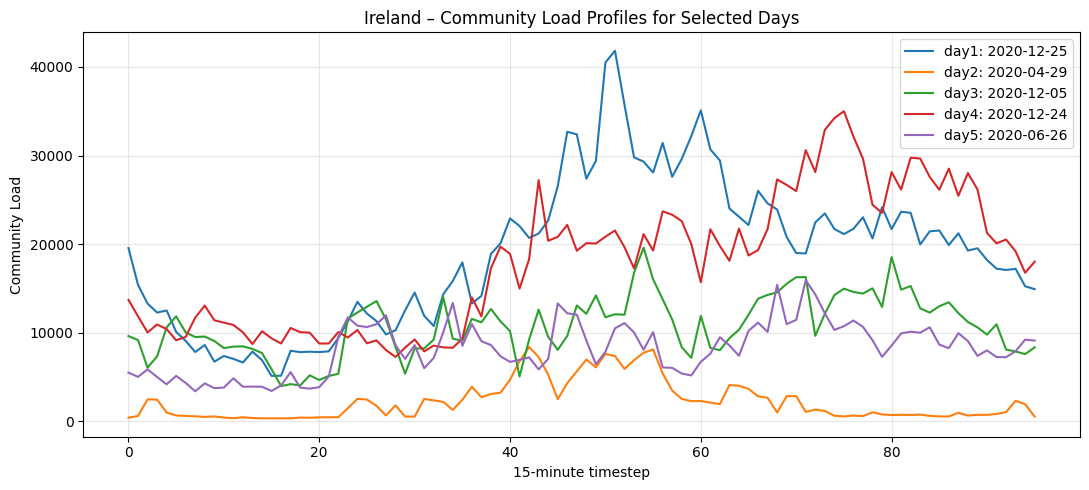

In [7]:
import matplotlib.pyplot as plt

def plot_selected_days_full(df, days_dict, title, freq="15min"):
    df = df.copy()
    df = df.sort_index()
    df.index = pd.to_datetime(df.index)

    home_cols = [c for c in df.columns if c.startswith("home_")]
    if "community_load" not in df.columns:
        df["community_load"] = df[home_cols].sum(axis=1)

    plt.figure(figsize=(11,5))

    for label, date_str in days_dict.items():
        start = pd.Timestamp(date_str)
        full_index = pd.date_range(start=start, periods=int(pd.Timedelta("1D")/pd.Timedelta(freq)), freq=freq)

        # reindex to full day grid -> ensures 96 points
        day_series = df.loc[start:start + pd.Timedelta(days=1), "community_load"].reindex(full_index)

        plt.plot(day_series.values, label=f"{label}: {date_str}")

        # optional: warn if incomplete (should not happen if you used the selector above)
        if day_series.isna().any():
            missing = int(day_series.isna().sum())
            print(f"Warning: {label} {date_str} still has {missing} missing steps.")

    plt.title(title)
    plt.xlabel("15-minute timestep")
    plt.ylabel("Community Load")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_selected_days_full(df_ireland, ireland_days, "Ireland – Community Load Profiles for Selected Days", freq="15min")